# ALS Genotype-Phenotype Analysis
This notebook analyzes the synthetic PROACT clinical dataset and the accompanying genetic variants (VCF).


In [1]:
!pip install pandas numpy matplotlib seaborn statsmodels lifelines scikit-allel -q


  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## 1. Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from lifelines import KaplanMeierFitter

# Set plot style
sns.set_theme(style="whitegrid")


## 2. Load Clinical and Genetic Data


In [3]:
# Load Clinical Data
clinical_df = pd.read_csv('synthetic_proact_dataset.csv')
print("Clinical Data Shape:", clinical_df.shape)
display(clinical_df.head())


Clinical Data Shape: (1000, 10)


,Patient_ID,Age_at_Onset,Sex,Site_of_Onset,Riluzole_Use,ALSFRS_R_Baseline,FVC_Baseline,ALSFRS_R_Slope,Time_to_Event_Days,Event_Occurred
0,PROACT_SYN_0001,62.0,Male,Limb,Yes,40.0,48.0,-2.246,134.0,1
1,PROACT_SYN_0002,54.3,Male,Limb,Yes,40.0,76.0,-0.850,196.0,1
2,PROACT_SYN_0003,63.8,Female,Limb,Yes,36.0,106.0,-1.632,329.0,0
3,PROACT_SYN_0004,74.3,Female,Limb,No,27.0,78.0,-1.312,34.0,1
4,PROACT_SYN_0005,53.2,Male,Bulbar,Yes,18.0,68.0,-1.207,204.0,1


In [4]:
# Load and parse VCF Data manually for simplicity
vcf_file = 'synthetic_cohort.vcf'
vcf_data = []

with open(vcf_file, 'r') as f:
    for line in f:
        if line.startswith('##'):
            continue
        if line.startswith('#CHROM'):
            columns = line.strip().split('\t')
            samples = columns[9:]
        else:
            parts = line.strip().split('\t')
            variant_id = parts[2]
            genotypes = parts[9:]
            # Convert '0/0', '0/1', '1/1' to 0, 1, 2
            gt_numeric = [gt.count('1') for gt in genotypes]
            vcf_data.append({
                'Variant_ID': variant_id,
                'Genotypes': gt_numeric
            })

# Create Genotype DataFrame
genetic_df = pd.DataFrame({d['Variant_ID']: d['Genotypes'] for d in vcf_data})
genetic_df['Patient_ID'] = samples

# Merge Datasets
merged_df = pd.merge(clinical_df, genetic_df, on='Patient_ID')
print("Merged Data Shape:", merged_df.shape)
display(merged_df.head())


Merged Data Shape: (1000, 17)


,Patient_ID,Age_at_Onset,Sex,Site_of_Onset,Riluzole_Use,ALSFRS_R_Baseline,FVC_Baseline,ALSFRS_R_Slope,Time_to_Event_Days,Event_Occurred,C9orf72_exp,SOD1_A4V,SOD1_D90A,rs12486783,rs11674437,rs11736730,rs35714649
0,PROACT_SYN_0001,62.0,Male,Limb,Yes,40.0,48.0,-2.246,134.0,1,0,0,0,1,1,0,1
1,PROACT_SYN_0002,54.3,Male,Limb,Yes,40.0,76.0,-0.850,196.0,1,0,0,0,1,0,0,0
2,PROACT_SYN_0003,63.8,Female,Limb,Yes,36.0,106.0,-1.632,329.0,0,0,0,0,1,1,0,0
3,PROACT_SYN_0004,74.3,Female,Limb,No,27.0,78.0,-1.312,34.0,1,0,0,0,1,1,0,1
4,PROACT_SYN_0005,53.2,Male,Bulbar,Yes,18.0,68.0,-1.207,204.0,1,0,0,0,0,1,0,0


## 3. Clinical Data Analysis


/Users/bcole/dbt_dagster/lib/python3.13/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/bcole/dbt_dagster/lib/python3.13/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/bcole/dbt_dagster/lib/python3.13/site-packages/scipy/_lib/_util.py:1272: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


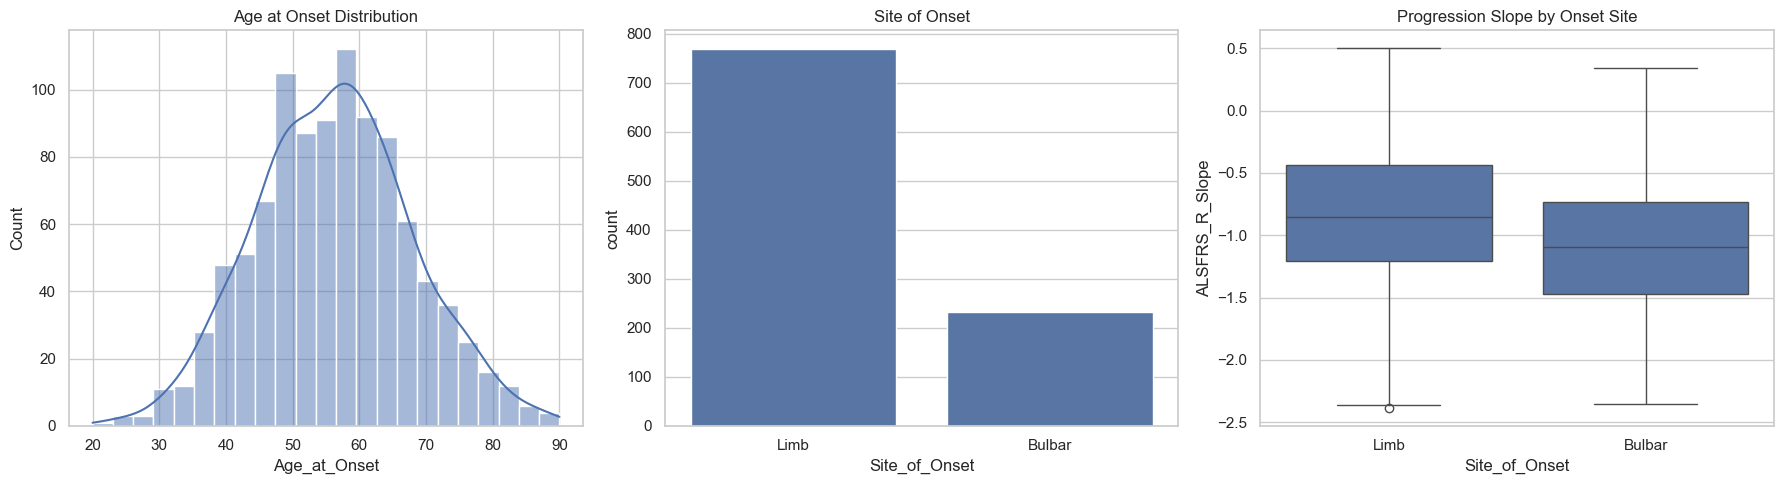

In [5]:
# Descriptive Statistics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=merged_df, x='Age_at_Onset', kde=True, ax=axes[0])
axes[0].set_title('Age at Onset Distribution')

sns.countplot(data=merged_df, x='Site_of_Onset', ax=axes[1])
axes[1].set_title('Site of Onset')

sns.boxplot(data=merged_df, x='Site_of_Onset', y='ALSFRS_R_Slope', ax=axes[2])
axes[2].set_title('Progression Slope by Onset Site')

plt.tight_layout()
plt.show()


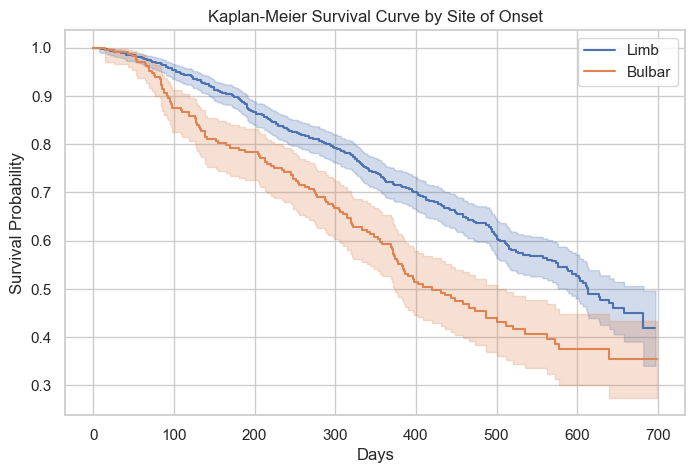

In [6]:
# Basic Survival Analysis (Bulbar vs Limb)
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 5))

for site in merged_df['Site_of_Onset'].unique():
    mask = merged_df['Site_of_Onset'] == site
    kmf.fit(merged_df['Time_to_Event_Days'][mask], 
            event_observed=merged_df['Event_Occurred'][mask], 
            label=site)
    kmf.plot_survival_function(ax=ax)

plt.title('Kaplan-Meier Survival Curve by Site of Onset')
plt.ylabel('Survival Probability')
plt.xlabel('Days')
plt.show()


## 4. Genetic Subtype Analysis
We define subtypes based on the Mendelian variants: `C9orf72` and `SOD1`.

First, plot the number of patients with each site of onset, stratified by SOD1 and C9orf72 genotype.

Then, plot a survival curve stratified by genotype: SOD1, C9orf72, and other (sporadic).

## 5. GWAS Analysis on Sporadic Cohort
Test the polygenic risk alleles against progression slope (ALSFRS-R). For each variant individually, is there a difference in progression slope among genotypes at that SNP?

Assemble a polygenic gene risk score defined as the sum of alleles (homozygous=2, het=1) times the OR for each of these risk SNPs. This is a measure of genetic burden. Is this score a significant predictor of progression slope in sporadic ALS cases?